# Fine-Tuning a Vehicle Classifier with LoRA (Pure TensorFlow/Keras)
### Stanford Cars (`cars196`) | Manual LoRA — No `peft`, No PyTorch

This notebook trains a **real LoRA adapter from scratch**, implemented by
hand in pure TensorFlow/Keras (`peft` is a PyTorch-only library, so this
version reimplements the LoRA math directly as a custom Keras layer).

**What this notebook does:**
- Loads the `cars196` (Stanford Cars) dataset via `tensorflow_datasets` —
  196 fine-grained vehicle classes (make/model/year)
- Loads a pretrained `MobileNetV2` (ImageNet weights) as a **frozen** feature extractor
- Replaces the classification head with a custom `LoRADense` layer that
  freezes its own base weight matrix and trains only two small low-rank
  matrices, `A` and `B`, on top of it
- Trains with `model.fit(...)` — a genuine forward pass, loss, backward
  pass, and optimizer step every batch
- Saves only the small trained LoRA weights (not the whole model), then
  reloads them for inference

**How this differs from the PyTorch/`peft` version:**
`peft.LoraConfig` + `get_peft_model()` insert LoRA into an *existing*
pretrained Dense/Linear layer (e.g. a ViT's query/value projections) without
you writing any low-rank math yourself. Plain TensorFlow/Keras has no
built-in LoRA layer, so here we write the `y = x@W + (alpha/r)*(x@A@B)`
computation ourselves inside a custom `tf.keras.layers.Layer`, with `W`
marked non-trainable and `A`/`B` marked trainable. The training mechanics
(freeze a matrix, backprop only into a small low-rank factor pair) are
identical — only the *code that expresses them* differs.

**Recommended environment:** Google Colab with a GPU runtime
(`Runtime -> Change runtime type -> T4 GPU` or better).


## Step 0 — Install Dependencies

In [3]:
%pip install -q -U tensorflow tensorflow-datasets matplotlib
%pip install -q -U importlib_resources etils

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Step 1 — Imports

In [3]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

print("\nAvailable Devices:")
print(tf.config.list_physical_devices())

tf.random.set_seed(42)

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

I0000 00:00:1784509662.714007    4660 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784509664.020815    4660 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784509669.197637    4660 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow Version: 2.21.0

Available Devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


E0000 00:00:1784509675.328217    4660 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Step 2 — Load the Vehicle Classification Dataset

`cars196` (the Stanford Cars dataset) contains 16,185 images across 196
fine-grained vehicle classes (e.g. "2012 Tesla Model S", "2009 Bugatti
Veyron 16.4"). `tensorflow_datasets` downloads and caches it automatically
the first time this cell runs.


In [4]:
CIFAR10_CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
VEHICLE_LABEL_IDS = [0, 1, 8, 9]  # airplane, automobile, ship, truck

(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

train_mask = np.isin(y_train_full, VEHICLE_LABEL_IDS)
test_mask = np.isin(y_test_full, VEHICLE_LABEL_IDS)

x_train_v = x_train_full[train_mask].astype("float32")
x_test_v = x_test_full[test_mask].astype("float32")

# Remap the original CIFAR-10 label ids down to a contiguous 0..3 range
label_map = {orig: new for new, orig in enumerate(VEHICLE_LABEL_IDS)}
y_train_v = np.array([label_map[l] for l in y_train_full[train_mask]], dtype=np.int64)
y_test_v = np.array([label_map[l] for l in y_test_full[test_mask]], dtype=np.int64)

class_names = [CIFAR10_CLASS_NAMES[i] for i in VEHICLE_LABEL_IDS]
num_classes = len(class_names)

print("Classes:", class_names)
print("Train examples:", len(x_train_v))
print("Test examples:", len(x_test_v))

ds_train = tf.data.Dataset.from_tensor_slices((x_train_v, y_train_v))
ds_test = tf.data.Dataset.from_tensor_slices((x_test_v, y_test_v))

Classes: ['airplane', 'automobile', 'ship', 'truck']
Train examples: 20000
Test examples: 4000


W0000 00:00:1784509692.598355    4660 cpu_allocator_impl.cc:82] Allocation of 245760000 exceeds 10% of free system memory.


W0000 00:00:1784509709.573494    4660 cpu_allocator_impl.cc:82] Allocation of 245760000 exceeds 10% of free system memory.


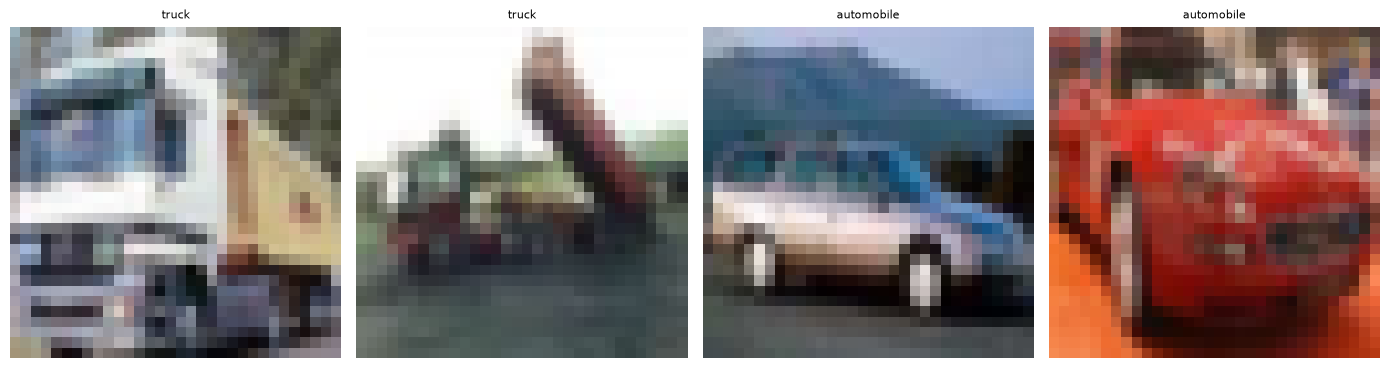

In [5]:
# Peek at a few training examples
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (image, label) in zip(axes, ds_train.take(4)):
    ax.imshow(image.numpy().astype("uint8"))
    ax.set_title(class_names[int(label.numpy())], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 3 — Preprocess and Batch

Images are resized to `224x224` and run through MobileNetV2's own
`preprocess_input` (scales pixels to the `[-1, 1]` range it expects).
Light augmentation (random flip) is applied only to the training split.


In [6]:
def format_train(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.random_flip_left_right(image)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

def format_eval(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

train_ds = (
    ds_train
    .map(format_train, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    ds_test
    .map(format_eval, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


## Step 4 — Load the Frozen Base Model

`MobileNetV2` pretrained on ImageNet acts as our frozen feature extractor
— the equivalent of the frozen base LLM/ViT in a text or image LoRA setup.
Setting `base_model.trainable = False` freezes every one of its weights;
none of them will receive a gradient during training.


In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    pooling="avg",
    weights="imagenet",
)
base_model.trainable = False

print("Base model layers:", len(base_model.layers))
print("Base model trainable params:",
      sum(int(tf.size(w)) for w in base_model.trainable_weights))


Base model layers: 155
Base model trainable params: 0


## Step 5 — Define LoRA by Hand (`LoRADense` Layer)

This is the core of the notebook — a from-scratch implementation of the
LoRA math, with no external LoRA library:

- `W` and `bias` are the layer's own base weight matrix — created with
  `trainable=False`, so the optimizer will never update them.
- `A` (`in_dim x r`) and `B` (`r x units`) are the trainable low-rank
  factors. `A` starts small and random, `B` starts at all zeros — exactly
  like real LoRA — so the layer's output at initialization equals the
  frozen path alone (`A @ B = 0`), and training only gradually shifts it.
- The forward pass computes `y = x @ W + bias + (alpha/r) * (x @ A @ B)`,
  matching the standard LoRA formula `h = W_0 x + (alpha/r) BA x`.

Because `W`/`bias` are marked `trainable=False`, Keras automatically
excludes them from `trainable_weights`, so `model.fit()` only ever
backpropagates into `A` and `B` (plus any other trainable layer you add).


In [8]:
class LoRADense(tf.keras.layers.Layer):
    """A Dense layer whose base weight matrix is frozen, adapted only
    through a trainable low-rank pair (A, B) — a from-scratch LoRA layer.
    """

    def __init__(self, units, rank=8, alpha=16, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.rank = rank
        self.alpha = alpha
        self.use_bias = use_bias

    def build(self, input_shape):
        in_dim = int(input_shape[-1])

        # Frozen base projection. In this from-scratch setup it is
        # initialized once and frozen immediately below; in a scenario
        # where you already had a trained Dense layer, you would instead
        # copy its existing trained weights in here before freezing.
        self.W = self.add_weight(
            name="frozen_kernel",
            shape=(in_dim, self.units),
            initializer="glorot_uniform",
            trainable=False,
        )
        if self.use_bias:
            self.bias = self.add_weight(
                name="frozen_bias",
                shape=(self.units,),
                initializer="zeros",
                trainable=False,
            )

        # Trainable LoRA factors.
        self.A = self.add_weight(
            name="lora_A",
            shape=(in_dim, self.rank),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
        )
        self.B = self.add_weight(
            name="lora_B",
            shape=(self.rank, self.units),
            initializer="zeros",
            trainable=True,
        )
        self.scaling = self.alpha / self.rank
        super().build(input_shape)

    def call(self, inputs):
        base_out = tf.matmul(inputs, self.W)
        if self.use_bias:
            base_out = base_out + self.bias
        lora_out = tf.matmul(tf.matmul(inputs, self.A), self.B) * self.scaling
        return base_out + lora_out

    def get_config(self):
        config = super().get_config()
        config.update({
            "units": self.units, "rank": self.rank,
            "alpha": self.alpha, "use_bias": self.use_bias,
        })
        return config


## Step 6 — Assemble the Full Model

Frozen `MobileNetV2` features feed into the `LoRADense` classification
head. Only `LoRADense`'s `A`/`B` matrices (and its frozen `W`/`bias`,
which stay untouched) sit on top of an entirely frozen backbone.


In [9]:
RANK = 8
ALPHA = 16

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
features = base_model(inputs, training=False)
outputs = LoRADense(num_classes, rank=RANK, alpha=ALPHA, name="lora_head")(features)

model = tf.keras.Model(inputs, outputs, name="mobilenetv2_lora_cars")
model.summary()


Model: "mobilenetv2_lora_cars"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lora_head (LoRADense)           │ (None, 4)              │        15,396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,380 (8.67 MB)

 Trainable params: 10,272 (40.12 KB)

 Non-trainable params: 2,263,108 (8.63 MB)

In [10]:
trainable_params = sum(int(tf.size(w)) for w in model.trainable_weights)
total_params = sum(int(tf.size(w)) for w in model.weights)

print(f"Trainable params: {trainable_params:,}")
print(f"Total params:     {total_params:,}")
print(f"Trainable %:      {trainable_params / total_params * 100:.4f}%")


Trainable params: 10,272
Total params:     2,273,380
Trainable %:      0.4518%


## Step 7 — Compile

Standard multi-class classification setup. Only `A` and `B` (and any
other trainable layer's weights — here, none besides those) will move
during training; `optimizer.apply_gradients()` never touches `W`/`bias`
because Keras excludes non-trainable weights from the gradient tape by
default under `model.fit()`.


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)


## Step 8 — Train

This is the real training loop: every batch runs a forward pass, computes
the loss, backpropagates, and takes an optimizer step — gradients only
flow into `A` and `B`.


In [12]:
EPOCHS = 3

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
)


Epoch 1/3


/home/dharmateja/.local/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1784509939.982502    4660 cpu_allocator_impl.cc:82] Allocation of 245760000 exceeds 10% of free system memory.


625/625 ━━━━━━━━━━━━━━━━━━━━ 453s 709ms/step - accuracy: 0.8661 - loss: 0.3424 - val_accuracy: 0.9057 - val_loss: 0.2693
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 777s 1s/step - accuracy: 0.9297 - loss: 0.1929 - val_accuracy: 0.9155 - val_loss: 0.2276
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 864s 1s/step - accuracy: 0.9358 - loss: 0.1741 - val_accuracy: 0.9193 - val_loss: 0.2282


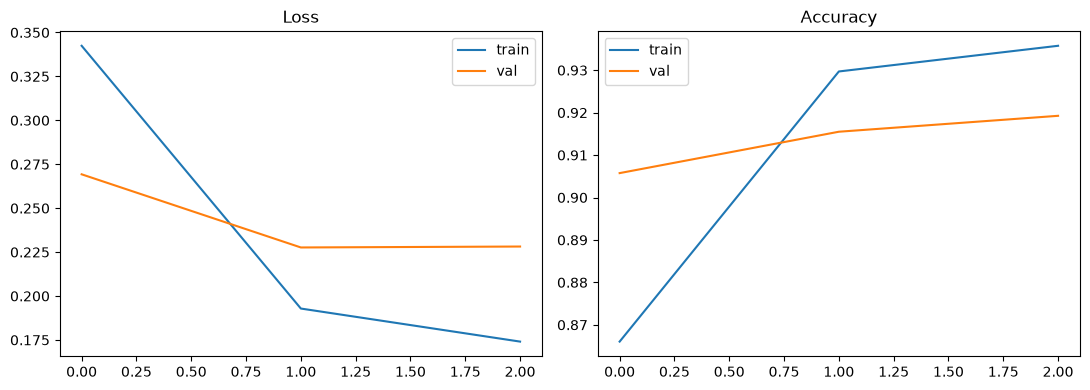

In [13]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


## Step 9 — Evaluate on the Test Set

In [14]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_accuracy:.4f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 95s 757ms/step - accuracy: 0.9193 - loss: 0.2282
Test loss: 0.2282 | Test accuracy: 0.9193


## Step 10 — Save Only the Trained LoRA Weights

Rather than saving the entire model (frozen backbone included), we save
just the small trained pieces — the `LoRADense` layer's `A`, `B`, and its
(untouched but still needed for reconstruction) frozen `W`/`bias`. This
mirrors saving a small `adapter_model.safetensors` in the `peft` world,
just in TensorFlow's native `.npz` format.


In [15]:
lora_layer = model.get_layer("lora_head")

np.savez(
    "cars_lora_adapter.npz",
    W=lora_layer.W.numpy(),
    bias=lora_layer.bias.numpy(),
    A=lora_layer.A.numpy(),
    B=lora_layer.B.numpy(),
    rank=RANK,
    alpha=ALPHA,
    num_classes=num_classes,
)
print("Saved adapter to cars_lora_adapter.npz")


Saved adapter to cars_lora_adapter.npz


## Step 11 — Reload the Adapter for Inference

Rebuilds the same frozen backbone + `LoRADense` head architecture, loads
the saved weights back in, and runs inference on a sample test image.


In [16]:
loaded = np.load("cars_lora_adapter.npz")

inference_base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, pooling="avg", weights=None,
)
inference_base.trainable = False

inf_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
inf_features = inference_base(inf_inputs, training=False)
inf_outputs = LoRADense(
    int(loaded["num_classes"]), rank=int(loaded["rank"]), alpha=int(loaded["alpha"]), name="lora_head",
)(inf_features)
inference_model = tf.keras.Model(inf_inputs, inf_outputs)

# Copy the base model's ImageNet weights (skipped above with weights=None
# to keep this cell fast/offline-friendly if run separately) and the
# saved LoRA weights into place. We assign each variable by name rather
# than using set_weights(), since Keras orders a layer's weights as
# trainable-first-then-non-trainable (not creation order), which makes
# positional set_weights() easy to get subtly wrong.
inference_model.get_layer(base_model.name).set_weights(base_model.get_weights())

lora_layer_inf = inference_model.get_layer("lora_head")
lora_layer_inf.W.assign(loaded["W"])
lora_layer_inf.bias.assign(loaded["bias"])
lora_layer_inf.A.assign(loaded["A"])
lora_layer_inf.B.assign(loaded["B"])

# Run inference on one test image
for image, label in ds_test.take(1):
    sample_image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    sample_input = tf.keras.applications.mobilenet_v2.preprocess_input(sample_image)
    sample_input = tf.expand_dims(sample_input, axis=0)

    logits = inference_model(sample_input, training=False)
    predicted_id = int(tf.argmax(logits, axis=-1)[0])

    print("Predicted:", class_names[predicted_id])
    print("Actual:   ", class_names[int(label.numpy())])


Predicted: ship
Actual:    ship


## Summary

- `MobileNetV2`'s pretrained ImageNet weights were frozen entirely —
  `base_model.trainable = False` — exactly like freezing a base LLM/ViT.
- `LoRADense` is a hand-written Keras layer that keeps its own base
  weight matrix frozen and trains only two small low-rank factors, `A`
  and `B`, initialized so the adapter starts as a no-op (`A @ B = 0`).
- `model.fit()` ran a genuine training loop — forward pass, loss,
  backward pass, optimizer step — with gradients reaching only `A`/`B`.
- The saved artifact (`cars_lora_adapter.npz`) is tiny compared to the
  full backbone, and is enough to reconstruct the fine-tuned classifier
  on top of the same frozen base model.

**Next steps to try:**
- Sweep `rank`/`alpha` to see the accuracy/parameter-count trade-off.
- Apply the same `LoRADense` pattern to an *existing* pretrained Dense
  layer (rather than a freshly initialized one) by copying its trained
  weights into `W` before freezing — closer to how `peft` adapts an
  already-trained projection.
- Swap `MobileNetV2` for a larger backbone (e.g. `EfficientNetB0` or
  `ResNet50`) and compare training time/accuracy.
